In [1]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [2]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps

In [3]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

def cubic_z_interp(h, field_vals_all, lon, lat, z_val):
    # Now make cubic interpolation coefficients for each grid staggering

    # Use the bottom four levels (in Python notation!)
    levels = [-1, -2, -3, -4]
    
    coeffs = np.zeros((4, len(lat), len(lon)))

    # Compute weights using interpolating polynomials
    coeffs[0] = (
        (z_val - h[levels[1]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[0]] - h[levels[1]]) * (h[levels[0]] - h[levels[2]])
        * (h[levels[0]] - h[levels[3]])
    )
    coeffs[1] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[1]] - h[levels[0]]) * (h[levels[1]] - h[levels[2]])
        * (h[levels[1]] - h[levels[3]])
    )
    coeffs[2] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[2]] - h[levels[0]]) * (h[levels[2]] - h[levels[1]])
        * (h[levels[2]] - h[levels[3]])
    )
    coeffs[3] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[2]])
    ) / (
        (h[levels[3]] - h[levels[0]]) * (h[levels[3]] - h[levels[1]])
        * (h[levels[3]] - h[levels[2]])
    )

    field_vals = np.zeros((len(lat), len(lon)))
    
    for i in np.arange(4):
        field_vals += coeffs[i]*field_vals_all[levels[i]]

    # Set values below surface to NaN
    field_vals = np.where(
        h[levels[0]] > z_val, np.nan, field_vals
    )
    
    return field_vals

In [4]:
savefig=True

rot = False

# Choose the dynamical core
#model = 'se'
model = 'fv3'
#model = 'mpas'

if model == 'se':
    dycore = 'CAM-SE'
    res = 'se_ne60'
    test_name_start = 'cam_6_4_100'
    lev_no = 'ztop20km_L57_new_RF'
    file_end = '.nc'
    
    extra_name1 = 'tau_100s'
    extra_name2 = 'tau_100s_diff_2x_weaker'
elif model == 'fv3':
    dycore = 'CAM-FV3'
    res = 'fv3_C192'
    test_name_start = 'cam_6_4_070_horiz_mount_flow'
    lev_no = 'ztop20km_L57_new_RF'
    file_end = '.regrid.0.5x0.5.nc'
    
    extra_name1 = 'tau100s'
    extra_name2 = 'tau100s_hord5'    
elif model == 'mpas':
    dycore = 'CAM-MPAS'
    res = 'mpasa60'
    test_name_start = 'cam_6_4_080_paper_six'
    lev_no = 'L20km_L57_new_RF_w0'
    file_end = '.regrid.0.5x0.5.nc'
    
    extra_name1 = 'tau100s'
    extra_name2 = 'tau100s_divfact_1' 
    #extra_name2 = 'tau100s_2d_fixed' 

case = f'{test_name_start}_{res}_{lev_no}'

# Compare three files
if rot:
    nc_file1 = f'{case}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name1}{file_end}'
    nc_file2 = f'{case}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name2}{file_end}'
else:
    nc_file1 = f'{case}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name1}{file_end}'
    nc_file2 = f'{case}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name2}{file_end}'


In [5]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case + '/run/' + nc_file1
run_path2 = run_base + case + '/run/' + nc_file2

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)

In [6]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 
lev = nc1['lev'][:]

print(np.size(lat), np.size(lon))

361 720


In [7]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat

lat_crop_up = 40.
lat_cent_down = 0.
lat_ticks = np.linspace(0,40,3)

lon_crop_left = 160.
lon_crop_right = 340.
lon_ticks = np.linspace(180., 340., 5)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

lon_lfric = lon_inds - 180

print(np.shape(lon_crop))

(361,)


In [8]:
# Time index to compare at
t_idx = 80

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [9]:
# Interpolations of U and T
u1 = cubic_z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u2 = cubic_z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v1 = cubic_z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v2 = cubic_z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T1 = cubic_z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T2 = cubic_z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [10]:
# Compute relative vorticity:
def compute_rel_vorticity(U, V, X, lat_crop, lon_crop, time):
    uv_ds = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], U), V=(['lat', 'lon'], V)), coords = dict(time=time, lat=lat_crop, lon=lon_crop))
    uv_ds['U'].attrs["units"] = "m/s"
    uv_ds['V'].attrs["units"] = "m/s"

    # Return the scaled relative vorticity on the small Earth
    return X*mpcalc.vorticity(uv_ds['U'], uv_ds['V'])

# Small Earth factor
X=20

vort_1 = compute_rel_vorticity(u1, v1, X, lat_crop, lon_crop, time[t_idx])
vort_2 = compute_rel_vorticity(u2, v2, X, lat_crop, lon_crop, time[t_idx])

In [11]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1 = (u1 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (u2 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

In [12]:
# What are the maximum values AWAY from the mountain??
lon_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]

U_max_crop1 = U_field_vals1[:,lon_max_inds]
vort_max_crop1 = vort_1[:,lon_max_inds]

U_max_crop2 = U_field_vals2[:,lon_max_inds]
vort_max_crop2 = vort_2[:,lon_max_inds]


min value is -1.8972513882737694
max value is 0.8555309854755493


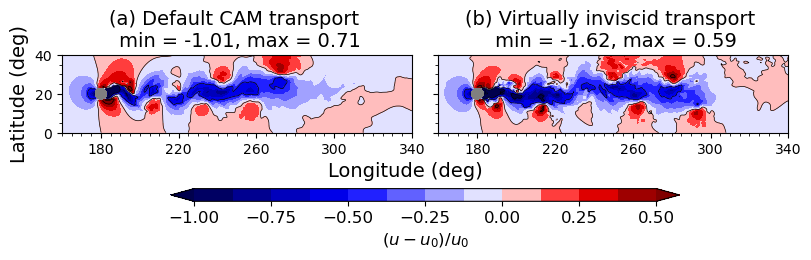

In [13]:
# Plot for U
U_cmap = matplotlib.cm.seismic
#U_cmap = matplotlib.cm.RdYlBu_r
#U_cmap.set_under('k')
#U_cmap.set_over('white')

#U_cmap = cmaps.ncl_default

U_max1 = np.nanmax(U_field_vals1)
U_max2 = np.nanmax(U_field_vals2)

U_min1 = np.nanmin(U_field_vals1)
U_min2 = np.nanmin(U_field_vals2)

U_maxmax = max(U_max1, U_max2)
U_minmin = min(U_min1, U_min2)

print('min value is', U_minmin)
print('max value is', U_maxmax)

fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,4), layout="constrained")
    
(ax1, ax2) = axes

U_conts = np.linspace(-1, 0.5, 13)
tick_range = np.linspace(-1, 0.5, 7)
norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=0.5)

U_conts_line = np.linspace(-1, 0.5, 4)


plot1 = ax1.contourf(LON, LAT, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
#plot4 = ax4.contourf(LON, LAT, U_field_vals4)
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, U_field_vals1, levels = U_conts_line, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, U_field_vals2, levels = U_conts_line, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

# Overall extrema
#ax1.set_title(f'{dycore1} \n min = {np.round(U_min1,2)}, max = {np.round(U_max1,2)}', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(U_min4,2)}, max = {np.round(U_max4,2)}', size=label_size)

# Extrema away from the mountain
if model == 'se':
    ax1.set_title(f'(a) Default CAM-SE diffusion \n min = {np.min(U_max_crop1):.2f}, max = {np.max(U_max_crop1):.2f}', size=label_size)
    ax2.set_title(f'(b) Half-strength diffusion \n min = {np.min(U_max_crop2):.2f}, max = {np.max(U_max_crop2):.2f}', size=label_size)
elif model == 'fv3':
    ax1.set_title(f'(a) Default CAM transport \n min = {np.min(U_max_crop1):.2f}, max = {np.max(U_max_crop1):.2f}', size=label_size)
    ax2.set_title(f'(b) Virtually inviscid transport \n min = {np.min(U_max_crop2):.2f}, max = {np.max(U_max_crop2):.2f}', size=label_size)
elif model == 'mpas':
    ax1.set_title(f'(a) Default MPAS diffusion \n min = {np.min(U_max_crop1):.2f}, max = {np.max(U_max_crop1):.2f}', size=label_size)
    ax2.set_title(f'(b) Weaker divergence diffusion \n min = {np.min(U_max_crop2):.2f}, max = {np.max(U_max_crop2):.2f}', size=label_size)


ax1.set_ylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.18)

if savefig:
    if rot:
        plt.savefig(f'figures/vortex_{model}_diffusion_with_rot_U.png')
    else:
        plt.savefig(f'figures/vortex_{model}_diffusion_omega0_U.png')


min value is -0.0031094482309657356
max value is 0.003921426634315562


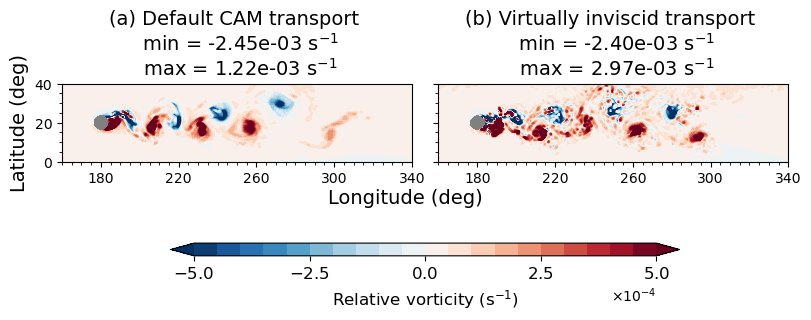

In [14]:
### T plot

cmap_choice = 'RdBu_r'

vort_max1 = np.nanmax(vort_1)
vort_max2 = np.nanmax(vort_2)

vort_min1 = np.nanmin(vort_1)
vort_min2 = np.nanmin(vort_2)

vort_maxmax = max(vort_max1, vort_max2)
vort_minmin = min(vort_min1, vort_min2)
absmax = 5e-4

print('min value is', vort_minmin)
print('max value is', vort_maxmax)

vort_conts = np.linspace(-absmax, absmax, 21)
vort_conts_line = np.linspace(-absmax, absmax, 3)
tick_range = np.linspace(-absmax, absmax, 5)
norm = colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

if rot:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
else:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,6.5), layout="constrained")

(ax1, ax2) = axes
    
plot1 = ax1.contourf(LON, LAT, vort_1, levels = vort_conts, cmap=cmap_choice, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, vort_2, levels = vort_conts, cmap=cmap_choice, norm=norm, extend = 'both')

T_title = 'Temperature perturbation'
for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label='Relative vorticity (s$^{-1}$)', size=small_size)
cb.ax.tick_params(labelsize=12)
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)

# Extrema over the full domain
#ax1.set_title(f'{dycore1} \n min = {np.round(T_min1,2)} K, max = {np.round(T_max1,2)} K', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(T_min2,2)} K, max = {np.round(T_max2,2)} K', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(T_min3,2)} K, max = {np.round(T_max3,2)} K', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(T_min4,2):.2f} K, max = {np.round(T_max4,2):.2f} K', size=label_size)

# Extrema away from the mountain
if model == 'se':
    ax1.set_title(f'(a) Default CAM-SE diffusion \n min = {np.nanmin(vort_max_crop1):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop1):.2e}' r" s$^{-1}$", size=label_size)
    ax2.set_title(f'(b) Half-strength CAM diffusion \n min = {np.nanmin(vort_max_crop2):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop2):.2e}' r" s$^{-1}$", size=label_size)
elif model == 'fv3':
    ax1.set_title(f'(a) Default CAM transport \n min = {np.nanmin(vort_max_crop1):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop1):.2e}' r" s$^{-1}$", size=label_size)
    ax2.set_title(f'(b) Virtually inviscid transport \n min = {np.nanmin(vort_max_crop2):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop2):.2e}' r" s$^{-1}$", size=label_size)
elif model == 'mpas':
    ax1.set_title(f'(a) Default CAM-MPAS diffusion \n min = {np.nanmin(vort_max_crop1):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop1):.2e}' r" s$^{-1}$", size=label_size)
    ax2.set_title(f'(b) Weaker divergence diffusion \n min = {np.nanmin(vort_max_crop2):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop2):.2e}' r" s$^{-1}$", size=label_size)


ax1.set_ylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.16)

if savefig:
    if rot:
        plt.savefig(f'figures/vortex_{model}_diffusion_with_rot_vort.png', bbox_inches='tight')
    else:
        plt.savefig(f'figures/vortex_{model}_diffusion_omega0_vort.png', bbox_inches='tight')


In [15]:
if model != 'fv3':
    yo

In [16]:
# What about a lat vert slice?
#Lat vert cross sections:
p0 = 1e5
Rd = 287.04
g = 9.80616
H = Rd*T0/g

lon = nc1['lon'][:] 
lat = nc1['lat'][:] 

lev1 = nc1['lev'][:] 
lev2 = nc2['lev'][:]

lon_crop_left = 150
lon_crop_right = 300

# User parameters:
t_idx = 40
field = 'W'

lon_ticks = np.linspace(lon_crop_left, lon_crop_right, 5)

lon_slice_inds = np.where((lon <= 220) & (lon >= 160))
lon_slice = lon[lon_slice_inds]

LONGC, P = np.meshgrid(lon_slice, lev)  

# Pick the latitude to slice at:
#lat_val = 95
lat_val = 220

lat_val_deg = np.round(lat[lat_val],0)
print('lat in deg is', lat_val_deg)

ps_t = nc1['PS'][t_idx, lat_val, lon_slice_inds[0]]/100

cmap_choice = 'coolwarm'

lat in deg is 20.0


57
95.36534881591797


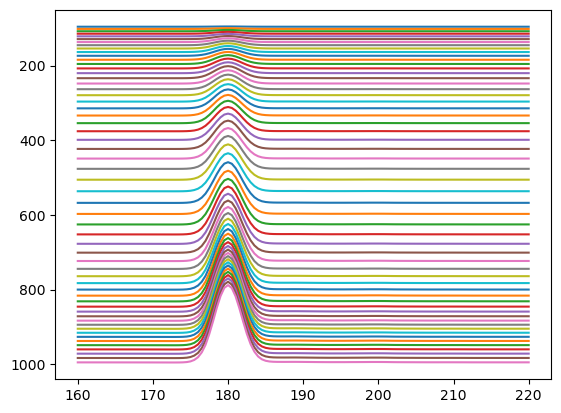

In [17]:
def compute_P_levels_readin(p0, ps):
    # Compute the p levels in a hybrid model.
    # Do for the interfaces, where the fields are defined.
    coords_path = '/glade/u/home/timand/vertical_grids/paper_six/cam_vcoords_dzlow100_dzmax500_top20km_L57.nc'
    coords_nc = Dataset(coords_path, 'r')

    hyam = coords_nc['hyam'][:]
    hybm = coords_nc['hybm'][:]

    lev_no = len(hyam)
    print(lev_no)

    # For interface levels
    p_vals = np.zeros((lev_no,len(ps)))
    for k in np.arange(lev_no):
        p_vals[k,:] = hyam[k]*p0 + hybm[k]*ps
                      
    return p_vals

P_layers = compute_P_levels_readin(1000, ps_t)

fig, ax = plt.subplots(1,1)
for i in np.arange(57):
    plt.plot(lon_slice, P_layers[i,:])

ax.invert_yaxis()

print(np.min(P_layers))

In [18]:
Rd = 287.04
g = 9.80616
# Convert P from hPa to Pa
P_Pa = P_layers*100
vert_slice1 = -(Rd/g)*nc1['OMEGA'][t_idx, :, lat_val, lon_slice_inds[0]]*nc1['T'][t_idx, :, lat_val, lon_slice_inds[0]]/P_Pa
vert_slice2 = -(Rd/g)*nc2['OMEGA'][t_idx, :, lat_val, lon_slice_inds[0]]*nc2['T'][t_idx, :, lat_val, lon_slice_inds[0]]/P_Pa

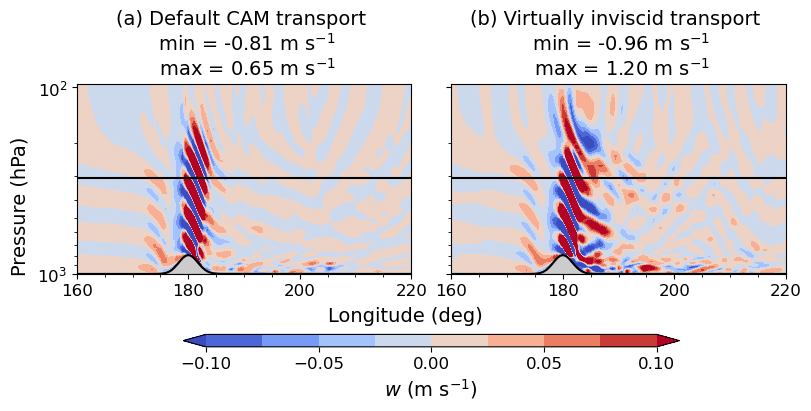

In [19]:
max1 = np.nanmax(vert_slice1)
max2 = np.nanmax(vert_slice2)

min1 = np.nanmin(vert_slice1)
min2 = np.nanmin(vert_slice2)

fig, axes = plt.subplots(1,2,figsize = (8,4), sharey=True, constrained_layout=True)
(ax1, ax2) = axes

minmin = -0.1
maxmax = 0.1

#minmin = -1
#maxmax = 1

absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)
plot1 = ax1.contourf(LONGC, P_layers, vert_slice1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC, P_layers, vert_slice2, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'
cb_label = 'm/s'
unit = 'm/s'

ax1.set_yscale('log')
ax2.set_yscale('log')

# Plot the sponge layer start:
pc = 305
pc_low =552.4

ax1.plot(lon_slice, pc*np.ones_like(lon_slice), c='k')
ax2.plot(lon_slice, pc*np.ones_like(lon_slice), c='k')

ax1.fill_between(lon_slice, ps_t, 1000, color='grey', alpha=0.4)
ax2.fill_between(lon_slice, ps_t, 1000, color='grey', alpha=0.4)
plt.ylim([96,1000])

ax1.invert_yaxis()

ax1.set_xticks([160,180,200,220])
ax2.set_xticks([160,180,200,220])
plt.xlim([160,220])

# Add the surface topography:
ax1.plot(lon_slice, ps_t, c='k')
ax2.plot(lon_slice, ps_t, c='k')

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

ax1.set_title(f'(a) Default CAM transport \n min = {min1:.2f} ' r"m s$^{-1}$" f'\n max = {max1:.2f} ' r"m s$^{-1}$", size=label_size)
ax2.set_title(f'(b) Virtually inviscid transport \n min = {min2:.2f} ' r"m s$^{-1}$" f'\n max = {max2:.2f} ' r"m s$^{-1}$", size=label_size)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.16, location='bottom')
cb.ax.tick_params(labelsize=12)
cb.set_label(r'$w$ (m s$^{-1}$)', size=14)

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.2)

ax1.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
ax2.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

# Only save this if savefig and FV3:
if savefig:
    if model == 'fv3':
        if rot:
            plt.savefig('figures/vortex_fv3_diffusion_vert_slice_with_rot.png', bbox_inches='tight')
        else:
            plt.savefig('figures/vortex_fv3_diffusion_vert_slice_omega0.png', bbox_inches='tight')
        